# **Projeto de Machine Learning**

## **APS1: Projeto EDA**

In [137]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Carregamento e Inspeção Inicial dos Dados:

In [138]:

with open("../data/adult.data", "r") as file:
    for i in range(5):
        print(file.readline())

39, State-gov, 77516, Bachelors, 13, Never-married, Adm-clerical, Not-in-family, White, Male, 2174, 0, 40, United-States, <=50K

50, Self-emp-not-inc, 83311, Bachelors, 13, Married-civ-spouse, Exec-managerial, Husband, White, Male, 0, 0, 13, United-States, <=50K

38, Private, 215646, HS-grad, 9, Divorced, Handlers-cleaners, Not-in-family, White, Male, 0, 0, 40, United-States, <=50K

53, Private, 234721, 11th, 7, Married-civ-spouse, Handlers-cleaners, Husband, Black, Male, 0, 0, 40, United-States, <=50K

28, Private, 338409, Bachelors, 13, Married-civ-spouse, Prof-specialty, Wife, Black, Female, 0, 0, 40, Cuba, <=50K



In [139]:
with open("../data/adult.names", "r") as file:
    for i, linha in enumerate(file):
        print(i, linha.strip())

0 | This data was extracted from the census bureau database found at
1 | http://www.census.gov/ftp/pub/DES/www/welcome.html
2 | Donor: Ronny Kohavi and Barry Becker,
3 |        Data Mining and Visualization
4 |        Silicon Graphics.
5 |        e-mail: ronnyk@sgi.com for questions.
6 | Split into train-test using MLC++ GenCVFiles (2/3, 1/3 random).
7 | 48842 instances, mix of continuous and discrete    (train=32561, test=16281)
8 | 45222 if instances with unknown values are removed (train=30162, test=15060)
9 | Duplicate or conflicting instances : 6
10 | Class probabilities for adult.all file
11 | Probability for the label '>50K'  : 23.93% / 24.78% (without unknowns)
12 | Probability for the label '<=50K' : 76.07% / 75.22% (without unknowns)
13 |
14 | Extraction was done by Barry Becker from the 1994 Census database.  A set of
15 |   reasonably clean records was extracted using the following conditions:
16 |   ((AAGE>16) && (AGI>100) && (AFNLWGT>1)&& (HRSWK>0))
17 |
18 | Prediction t

Após uma análise dos arquivos "adult.data" e "adult.names" foi possível descobrir o nome das colunas em ordem para a estruturação do dataframe: 

**Variável Alvo (Target)**
---
`income`: Indica se a renda anual é maior ou menor que 50 mil dólares.

**Características Demográficas e Sociais**
---
* `age` Idade da pessoa em anos. (Contínua)

* `race` Raça declarada.(Categorias: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.)

* `sex` Sexo biológico. (Categorias: Female, Male.)

* `native-country` País de origem da pessoa. (Exemplos: United-States, Mexico, Philippines, Germany, etc. (Mais de 40 países).)

**Educação**
---
* `education` Nível educacional da pessoa. (Exemplos: Bachelors, Some-college, 11th, HS-grad, Masters, Doctorate, etc.)

* `education-num` Representação numérica do nível educacional. (contínua. Geralmente, quanto maior o número, maior o nível de escolaridade.)

**Vida Civil e Relacionamentos**
---
* `marital-status` Estado civil da pessoa. (Categorias: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, etc.)

* `relationship` Papel da pessoa na estrutura familiar. (Categorias: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.)


**Trabalho e Ocupação**
---
* `hours-per-week` Número de horas trabalhadas por semana. (Contínua)

* `workclass` Tipo de empregador ou setor de trabalho. (Categorias: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.)

* `occupation` Profissão ou ocupação da pessoa. (Categorias: Tech-support, Craft-repair, Exec-managerial, Prof-specialty, Sales, etc.)


**Variáveis Financeiras e Técnicas**
---
* `capital-gain` Ganhos de capital (Contínua. Lucro com venda de ativos).

* `capital-loss` Perdas de capital (Contínua. Prejuízos financeiros).

* `fnlwgt` Peso amostral atribuído pelo Census Bureau. (Explicação: É uma estimativa de quantas pessoas na população real aquele registro representa, baseada em características socio-demográficas semelhantes.)




In [140]:
colunas = ["age", "workclass", "fnlwgt", "education", 
           "education-num", "marital-status", "occupation",
           "relationship", "race", "sex", "capital-gain", 
           "capital-loss", "hours-per-week", "native-country", "income"]

df = pd.read_csv("../data/adult.data", names=colunas, sep=",")

for c in df.columns:
    if df[c].dtype == "str":
        df[c] = df[c].str.strip() 

df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [141]:
print("Shape:", df.shape)
print("Duplicatas:", df.duplicated().sum())

print("\nTipos de dados:")
print(df.dtypes)

print("\nDistribuição do target:")
print(df["income"].value_counts(normalize=True))

Shape: (32561, 15)
Duplicatas: 24

Tipos de dados:
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

Distribuição do target:
income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64


In [142]:
rows_all_null = df.isna().all(axis=1).sum()
rows_some_null = df.isna().any(axis=1) & ~df.isna().all(axis=1)

print("Número de linhas com todas as features são nulas: ", rows_all_null.sum())
print("Número de linhas com algumas (não todas) features nulas: ", rows_some_null.sum())
print("\n")

#-----------------------------------------------------------------------------------------------------------------
print("Campos com valores ausentes do tipo: '?'")

for c in df.columns:
    qtd = (df[c] == "?").sum()
    if qtd > 0:
        print(f"{c}: {qtd}")

print("\n")

#------------------------------------------------------------------------------------------------------------------
info_df = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.values
})

num = [c for c in df.columns if df[c].dtype == "int64"]
cat = [c for c in df.columns if df[c].dtype == "str"]

print(f"Dados numéricos: {len(num)} -> {num}")
print(f"Dados categóricos: {len(cat)} -> {cat}")
print("\n")


Número de linhas com todas as features são nulas:  0
Número de linhas com algumas (não todas) features nulas:  0


Campos com valores ausentes do tipo: '?'
workclass: 1836
occupation: 1843
native-country: 583


Dados numéricos: 6 -> ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Dados categóricos: 9 -> ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']




### 2. Análise Univariada:

In [143]:

print(df[num].describe())


                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


#### Estatísticas Descritivas — Variáveis Numéricas

- **`age`**: média de aproximadamente 38 anos e mediana de 37 anos, indicando uma distribuição levemente assimétrica à direita.
- **`education-num`**: média e mediana próximas de 10, correspondendo aproximadamente ao nível HS-grad, o que sugere predominância de indivíduos com ensino médio completo.
- **`hours-per-week`**: média e mediana próximas de 40 horas semanais, refletindo a jornada de trabalho mais comum no conjunto de dados.
- **`capital-gain` / `capital-loss`**: apresentam média muito baixa e mediana igual a zero, indicando que a maior parte dos indivíduos não possui ganhos ou perdas de capital. As duas variáveis também mostram forte assimetria.
- **`fnlwgt`**: apresenta alta variabilidade, mas possui baixa relevância interpretativa direta para a tarefa de predição da renda.

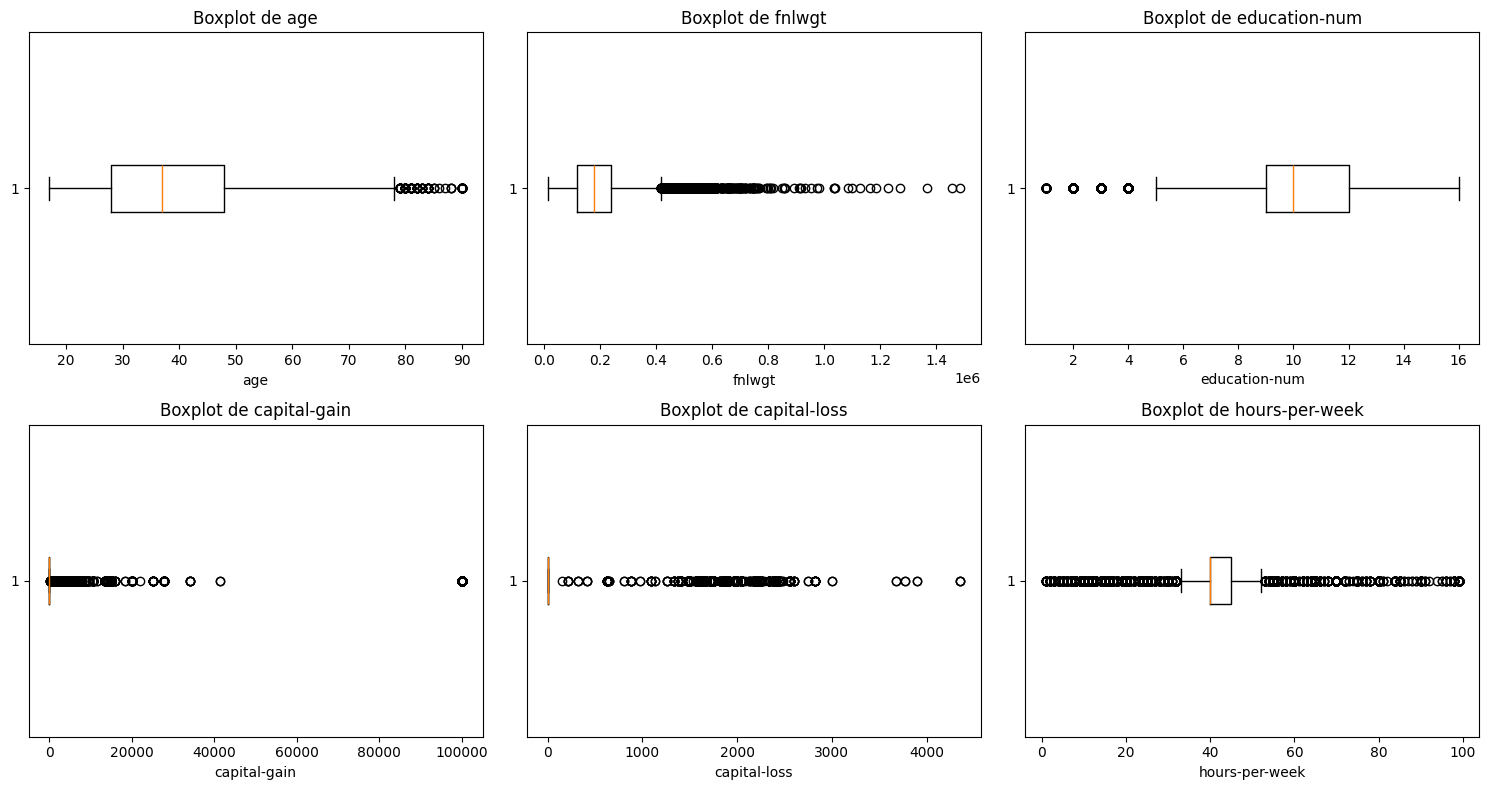

age: 143 outliers
fnlwgt: 992 outliers
education-num: 1198 outliers
capital-gain: 2712 outliers
capital-loss: 1519 outliers
hours-per-week: 9008 outliers


In [144]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, c in enumerate(num):
    axes[i].boxplot(df[c], vert=False)
    axes[i].set_title(f"Boxplot de {c}")
    axes[i].set_xlabel(c)

plt.tight_layout()
plt.show()


for c in num:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[c] < lower_bound) | (df[c] > upper_bound)]
    print(f"{c}: {len(outliers)} outliers")


#### Outliers — Método IQR

- **`capital-gain` e `capital-loss`**: apresentaram grande quantidade de outliers segundo o critério do IQR. Entretanto, esses valores parecem corresponder a situações reais, relacionadas a ganhos e perdas financeiras, e não a erros de registro. Por esse motivo, optou-se por não removê-los.
- **`age`**: os valores considerados extremos correspondem, em geral, a indivíduos com idade mais elevada, o que é plausível dentro do contexto do conjunto de dados.
- **`hours-per-week`**: os outliers identificados representam jornadas de trabalho muito baixas ou muito altas, mas ainda compatíveis com situações reais.
- **`fnlwgt`**: também apresentou valores extremos, porém essa variável possui menor relevância interpretativa para o objetivo principal de predição da renda.

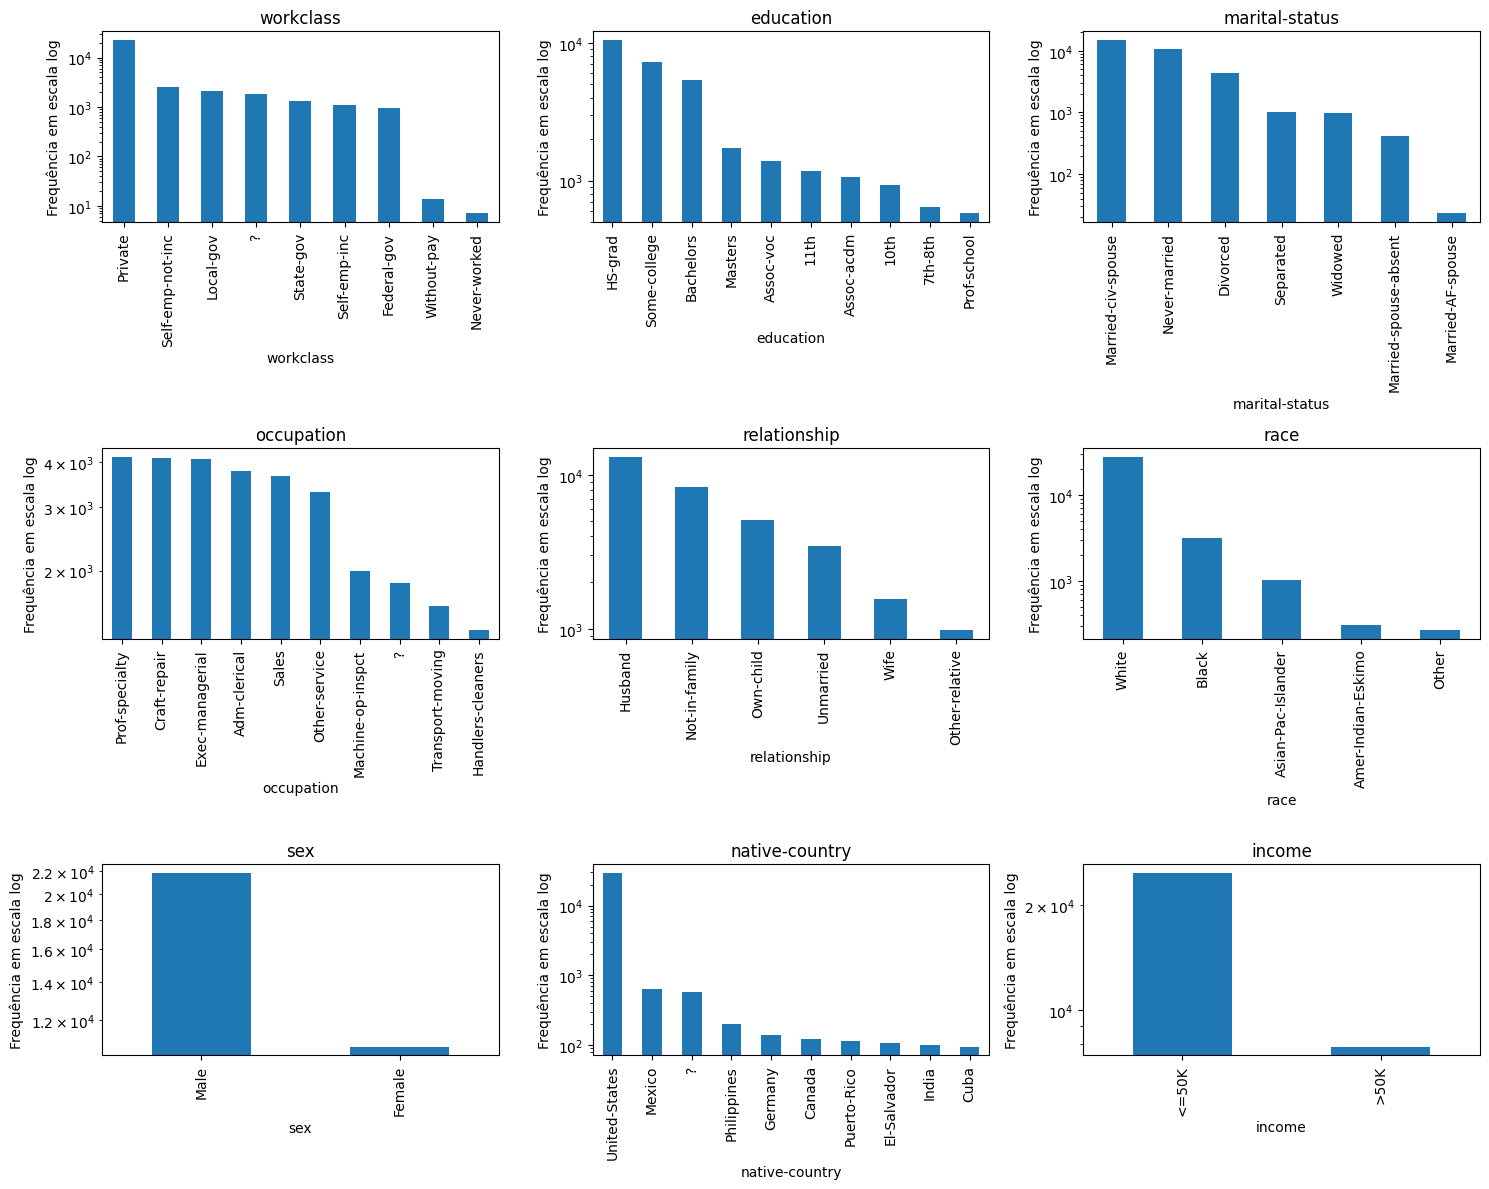

In [145]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
plt.title("Frquências em variáveis categóricas")

for i, col in enumerate(cat):
    df[col].value_counts().head(10).plot(kind='bar', ax=axes[i], title=col, logy=True)
    axes[i].set_ylabel('Frequência em escala log')

plt.tight_layout()
plt.show()

#### Frequências — Variáveis Categóricas

- **`workclass`**: a categoria `"Private"` é claramente predominante no conjunto de dados. Já categorias como `"Without-pay"` e `"Never-worked"` possuem frequência muito baixa, podendo ser consideradas para agrupamento em etapas futuras.
- **`education`**: algumas categorias apresentam poucos registros, como `"Preschool"` e `"1st-4th"`, o que pode justificar eventual agrupamento para simplificar a análise.
- **`native-country`**: observa-se forte concentração da categoria `"United-States"`, indicando baixa diversidade geográfica no conjunto de dados.
- **`race`** e **`sex`**: apresentam distribuições desbalanceadas, com predominância de indivíduos identificados como `"White"` e `"Male"`, o que pode refletir viés de representação.
- **`occupation`** e **`marital-status`**: apresentam distribuição mais variada, com categorias relativamente bem representadas.

### 3. Análise Bivariada e Multivariada:


#### Analise de correlações entre variáveis numéricas por meio de matrizes de correlação e scatter plots

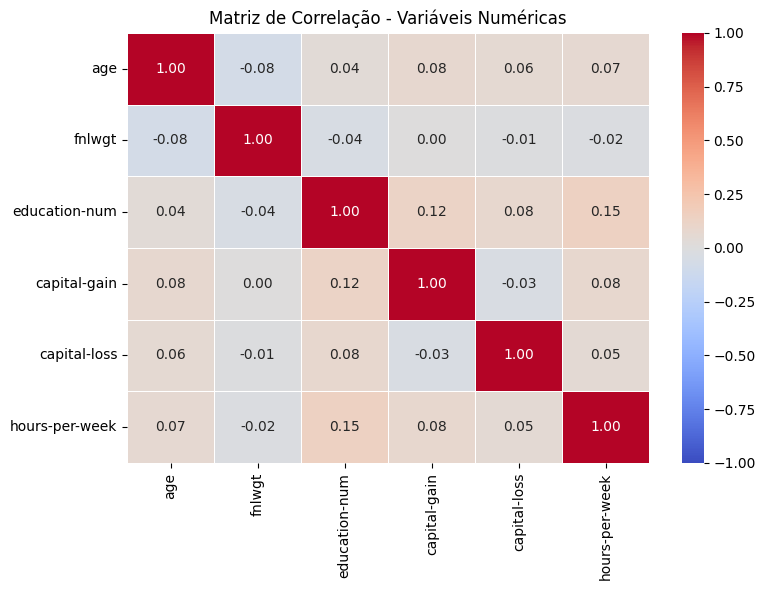

In [146]:
corr_matrix = df[num].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.tight_layout()
plt.show()

#### Correlações entre Variáveis Numéricas

- As correlações entre as variáveis numéricas são, em geral, baixas, o que sugere pouca multicolinearidade entre os atributos.
- **`age`** e **`education-num`** apresentam correlação positiva fraca, indicando que não há relação linear forte entre idade e nível educacional.
- **`capital-gain`** e **`capital-loss`** possuem correlação próxima de zero, o que sugere independência entre essas variáveis.
- Entre as variáveis numéricas, **`education-num`** se destaca por apresentar a associação mais relevante com a renda.

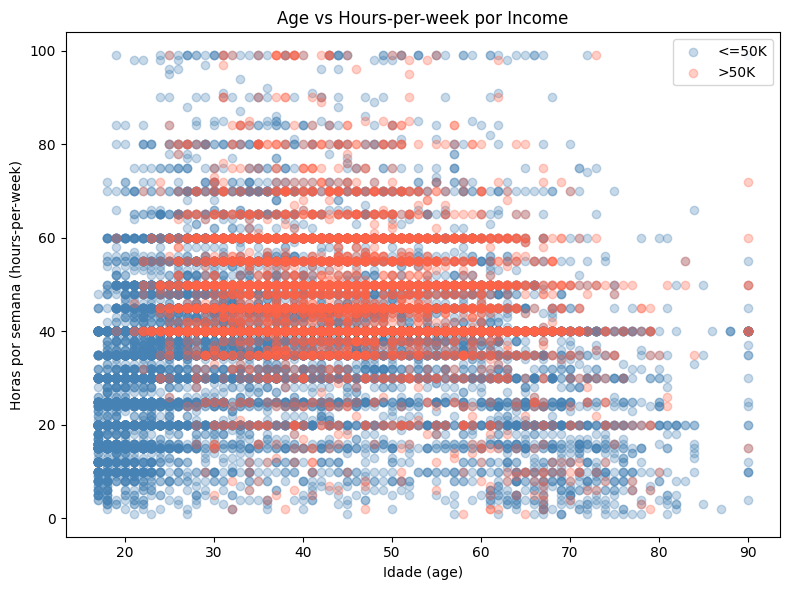

In [147]:
plt.figure(figsize=(8, 6))
for classe, cor in [("<=50K", "steelblue"), (">50K", "tomato")]:
    subset = df[df["income"] == classe]
    plt.scatter(subset["age"], subset["hours-per-week"], label=classe, alpha=0.3, color=cor)

plt.xlabel("Idade (age)")
plt.ylabel("Horas por semana (hours-per-week)")
plt.title("Age vs Hours-per-week por Income")
plt.legend()
plt.tight_layout()
plt.show()

#### Scatter Plot — Age vs Hours-per-week por Income

- Indivíduos com renda **`>50K`** tendem a se concentrar mais frequentemente em faixas intermediárias de idade e em jornadas de trabalho mais elevadas.
- Apesar disso, observa-se grande sobreposição entre as duas classes no gráfico, indicando que essas variáveis, isoladamente, não são suficientes para separar de forma clara os grupos de renda.

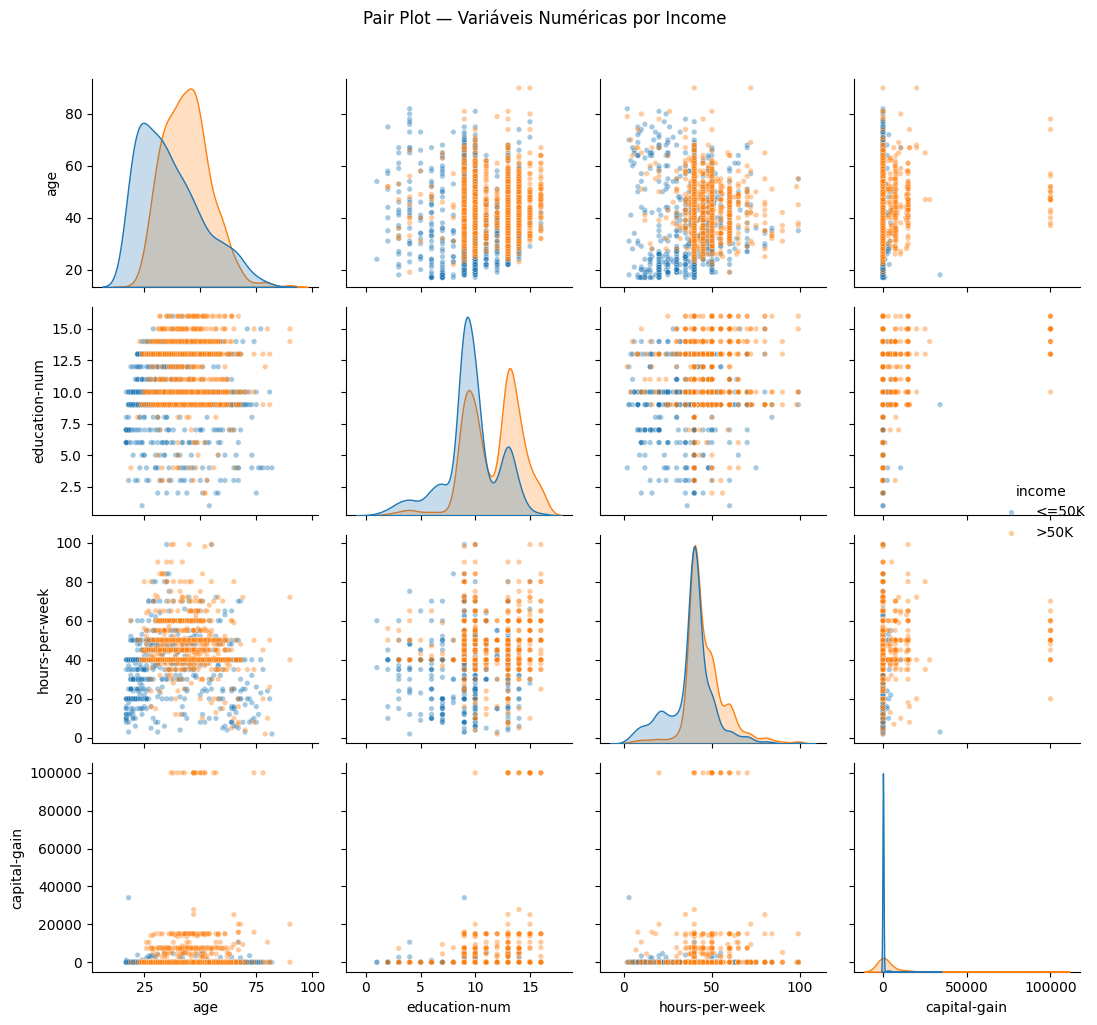

In [148]:
# Usar uma amostra estratificada 
amostra = df.groupby("income", group_keys=False).sample(n=1000, random_state=42)

sns.pairplot(
    amostra[["age", "education-num", "hours-per-week", "capital-gain", "income"]],
    hue="income",         
    plot_kws={"alpha": 0.4, "s": 15},
    diag_kind="kde"       
)
plt.suptitle("Pair Plot — Variáveis Numéricas por Income", y=1.02)
plt.tight_layout()
plt.show()

#### Pair Plot — Variáveis Numéricas por Income

- As variáveis **`education-num`** e **`age`** apresentam a separação visual mais perceptível entre as classes de renda.
- A variável **`capital-gain`** apresenta muitos valores iguais a zero, mas os registros com valores positivos aparecem com maior frequência na classe **`>50K`**.
- De forma geral, os gráficos indicam que a separação entre as classes depende da combinação de múltiplas variáveis, e não apenas de um único atributo.

#### Analise das relações entre variáveis categóricas e o target 'income' utilizando gráficos de barras.


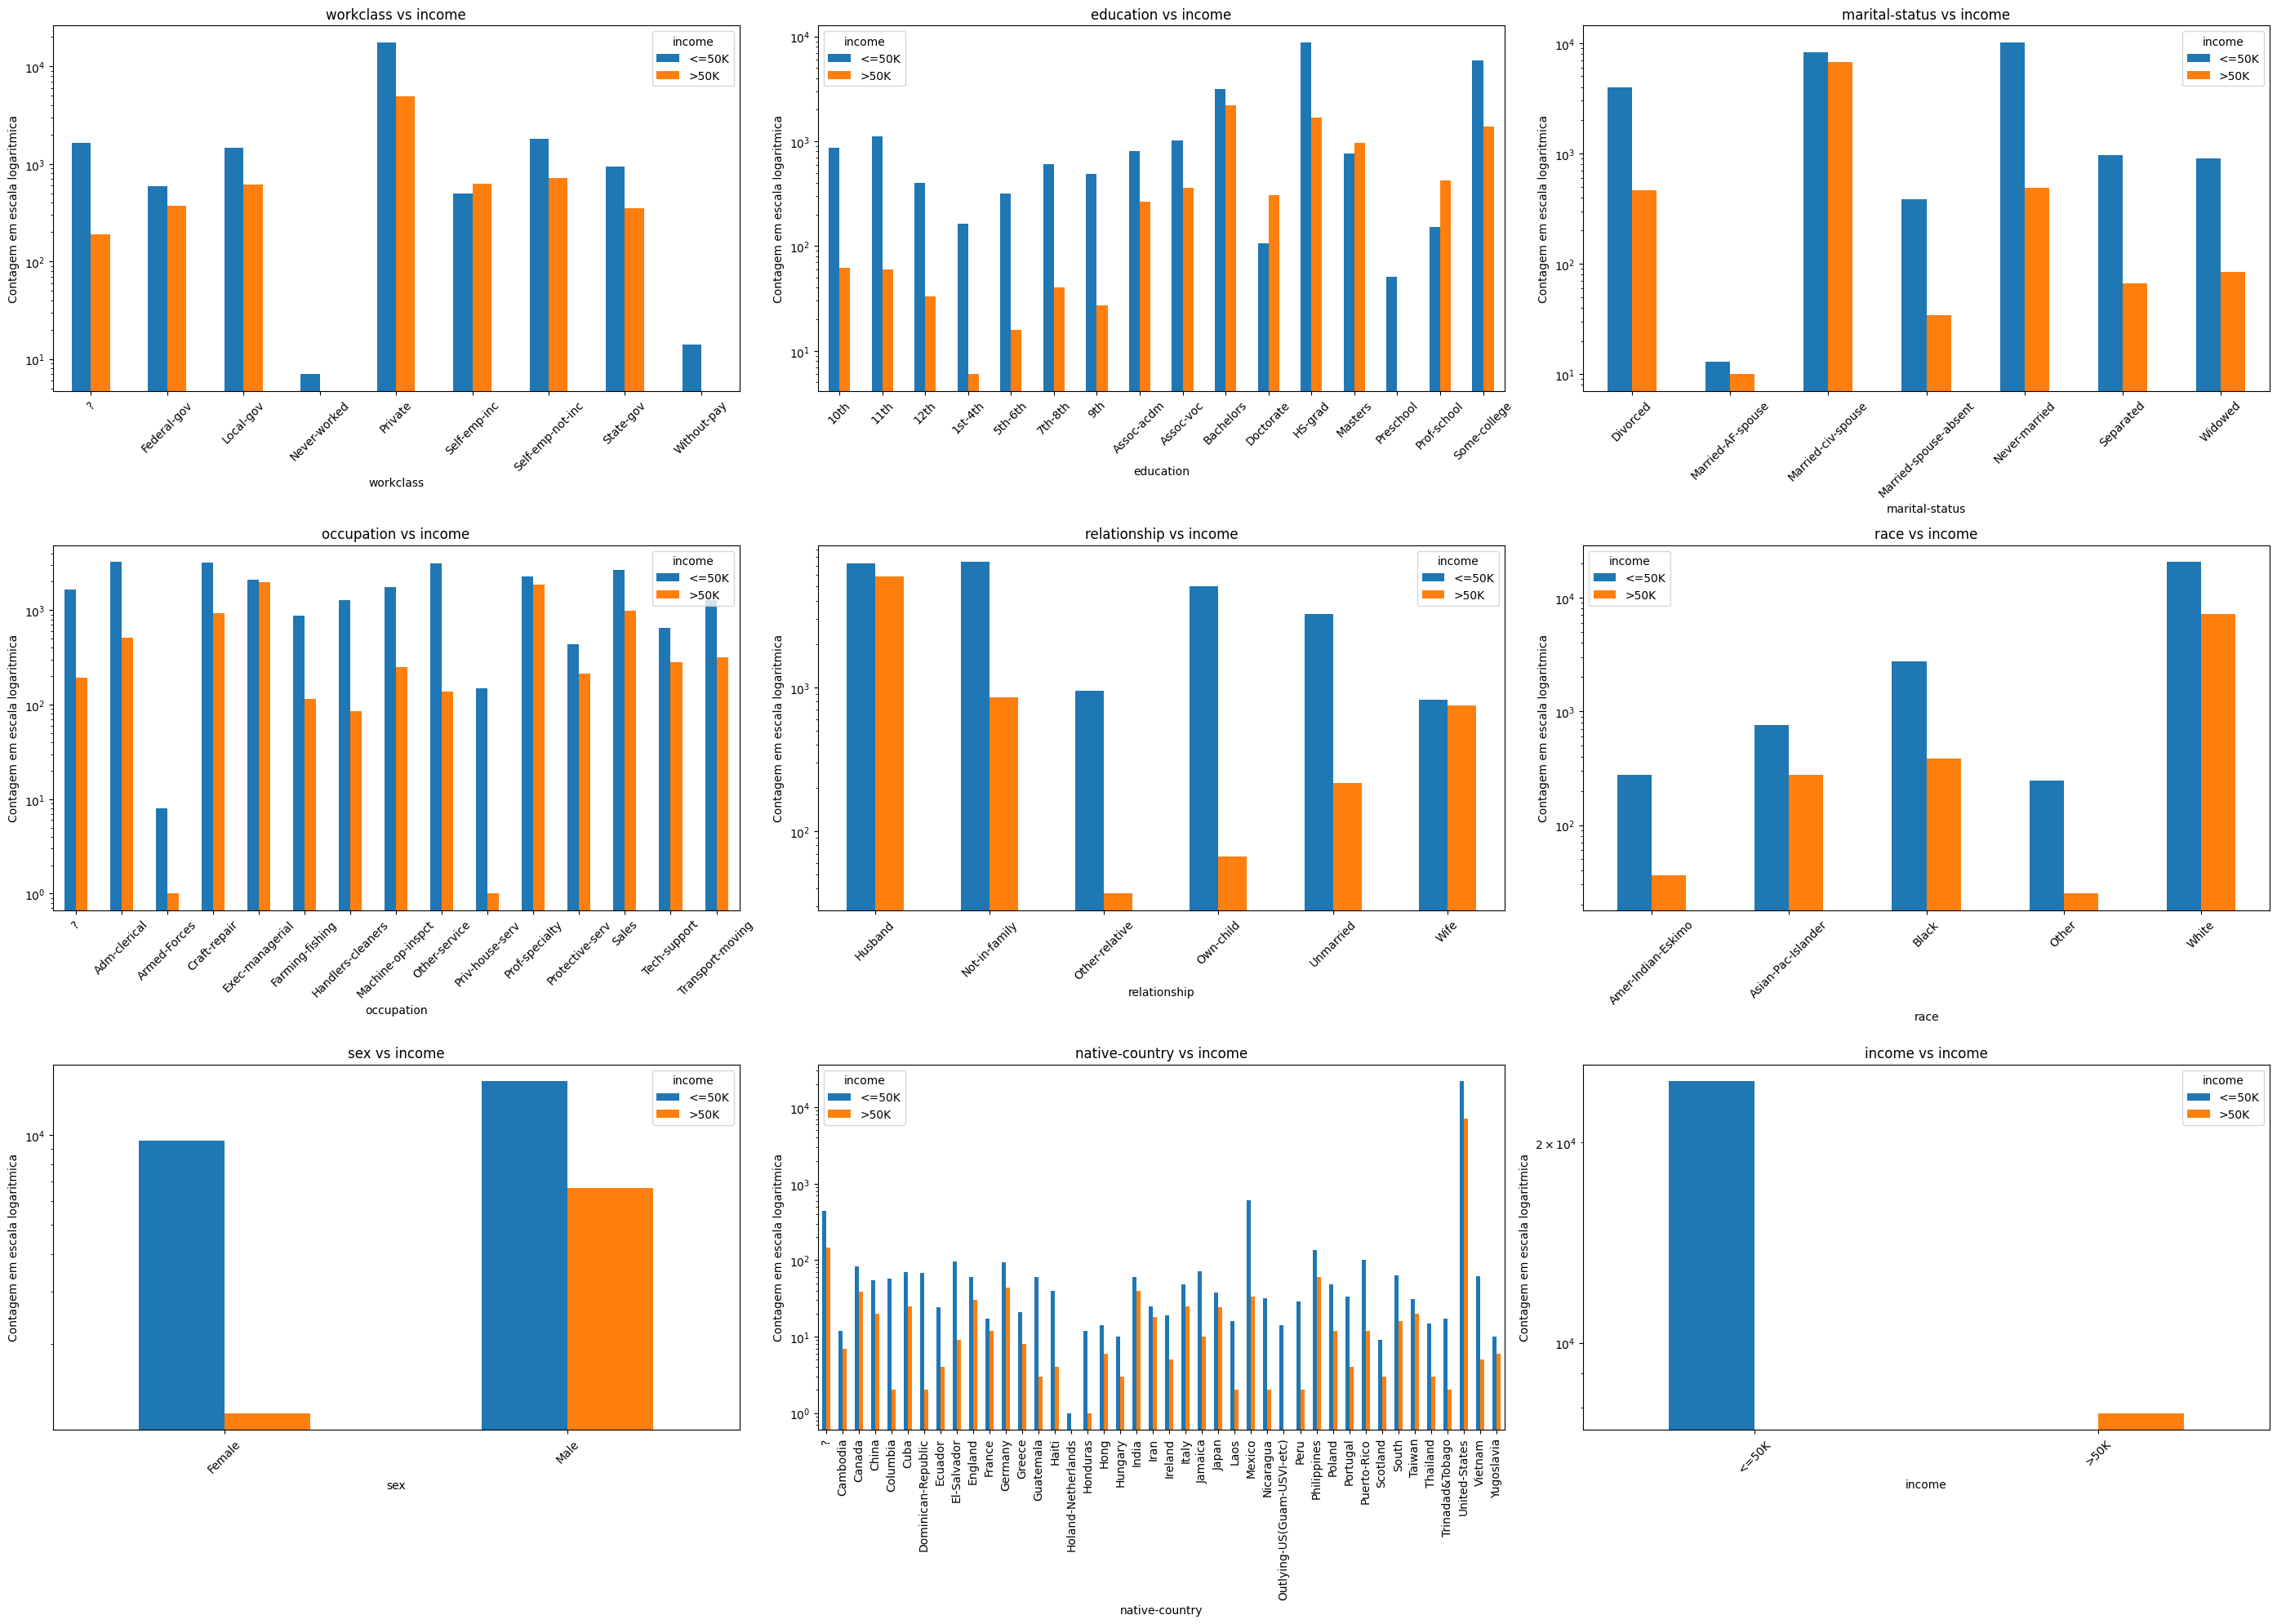

In [149]:
cat_copy = cat.copy()

fig, axes = plt.subplots(3, 3, figsize=(28, 20))
axes = axes.flatten() 

for i, col in enumerate(cat_copy):
    contingency = pd.crosstab(df[col], df['income'])
    contingency.plot(
        kind='bar',
        ax=axes[i],
        logy=True, 
        
    )
    
    axes[i].set_title(f'{col} vs income')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Contagem em escala logaritmica')
    axes[i].tick_params(axis='x', rotation=45)
    if col == "native-country":
        axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

#### Variáveis Categóricas vs Income

- **`education`**: níveis educacionais mais altos, como `"Bachelors"`, `"Masters"` e `"Doctorate"`, estão associados a maior proporção de indivíduos com renda **`>50K`**.
- **`marital-status`**: a categoria `"Married-civ-spouse"` apresenta a maior concentração relativa de indivíduos com renda mais alta, sugerindo forte associação com a variável alvo.
- **`occupation`**: ocupações como `"Exec-managerial"` e `"Prof-specialty"` apresentam maior proporção de renda **`>50K`**.
- **`workclass`**: embora o setor privado concentre a maior parte dos registros, algumas categorias do setor público apresentam proporção relativamente elevada de indivíduos com renda mais alta.
- **`sex`**: observa-se maior proporção de renda **`>50K`** entre homens, o que pode indicar viés de gênero presente no conjunto de dados.
- **`race`**: algumas categorias, como `"White"` e `"Asian-Pac-Islander"`, apresentam maior proporção de indivíduos com renda superior a 50 mil dólares em comparação com as demais.

#### Analise das relações entre variáveis numéricas e categóricas utilizando boxplots.


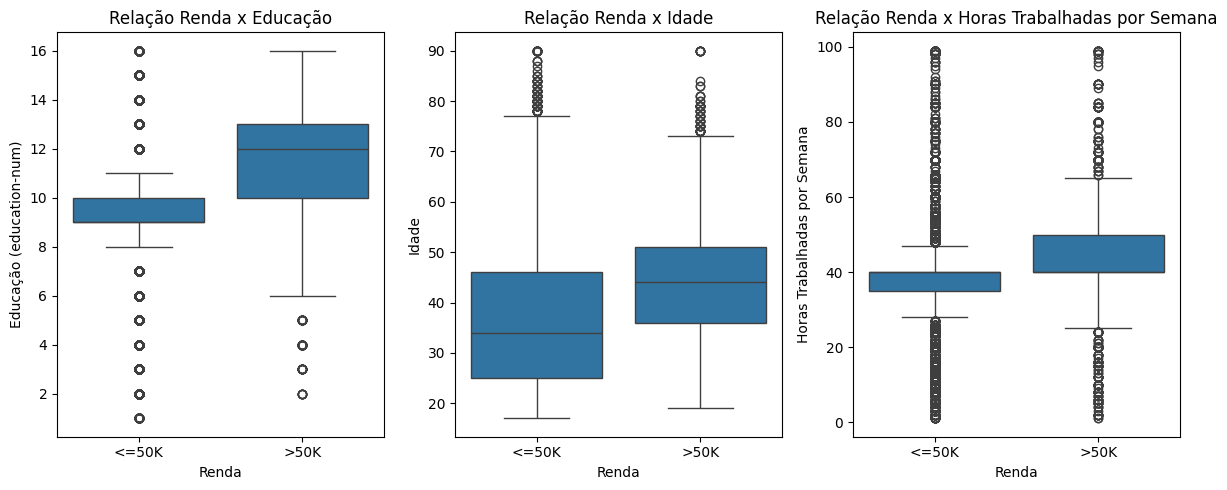

In [150]:
fig, axes = plt.subplots(1, 3, figsize=(12,5))

sns.boxplot(data=df, x='income', y='education-num', orient='v', ax=axes[0])
axes[0].set_xlabel("Renda")
axes[0].set_ylabel("Educação (education-num)")
axes[0].set_title("Relação Renda x Educação")

sns.boxplot(data=df, x='income', y='age', orient='v', ax=axes[1])
axes[1].set_xlabel("Renda")
axes[1].set_ylabel("Idade")
axes[1].set_title("Relação Renda x Idade")

sns.boxplot(data=df, x='income', y='hours-per-week', orient='v', ax=axes[2])
axes[2].set_xlabel("Renda")
axes[2].set_ylabel("Horas Trabalhadas por Semana")
axes[2].set_title("Relação Renda x Horas Trabalhadas por Semana")

plt.tight_layout()
plt.show()

#### Boxplots — Variáveis Numéricas vs Income

- **`education-num`**: apresenta mediana mais alta para a classe **`>50K`**, indicando que níveis mais elevados de escolaridade estão associados a maiores rendas.
- **`age`**: indivíduos com renda superior a 50 mil dólares tendem a ser, em média, mais velhos do que aqueles da classe **`<=50K`**.
- **`hours-per-week`**: a classe **`>50K`** apresenta maior quantidade de horas trabalhadas por semana, embora a diferença seja menos acentuada do que nas demais variáveis.
- De forma geral, os resultados indicam que **`education-num`**, **`age`** e **`marital-status`** estão entre os atributos mais relevantes para diferenciar os grupos de renda.

### 4. Análise de Qualidade dos Dados:

#### Qualidade dos Dados

**Valores ausentes (`?`):**
- Foram identificados valores ausentes representados por `?` nas variáveis **`workclass`** (1836 casos, aproximadamente 5,6%), **`occupation`** (1843 casos, aproximadamente 5,7%) e **`native-country`** (583 casos, aproximadamente 1,8%).
- A presença desses valores exige tratamento antes da etapa de modelagem, para evitar impacto negativo no desempenho dos algoritmos.
- Entre as estratégias possíveis, destacam-se a substituição pela moda, a remoção dos registros afetados ou a criação de uma categoria específica, como **`Unknown`**.


**Desequilíbrio de classes:**
- A variável alvo apresenta distribuição desbalanceada, com predominância da classe **`<=50K`** (aproximadamente 75%) em relação à classe **`>50K`** (aproximadamente 25%).
- Esse desequilíbrio pode levar o modelo a favorecer a classe majoritária, reduzindo a capacidade de identificar corretamente a classe minoritária.


**Vieses e inconsistências:**
- Observa-se possível **viés de gênero**, já que mulheres estão menos representadas, especialmente na classe de maior renda.
- Há também **viés racial**, com predominância de indivíduos da categoria `"White"` no conjunto de dados.
- O forte predomínio de `"United-States"` em **`native-country`** sugere **viés geográfico**, o que pode limitar a generalização do modelo.
- Além disso, por se tratar de dados de 1994, existe uma limitação temporal importante, pois os padrões socioeconômicos podem não representar a realidade atual.

### 5. Pré-processamento para Modelagem:

In [155]:
import numpy as np

df_model = df.copy()
df_model = df_model.replace("?", np.nan)
print("Shape antes: ", df_model.shape)

df_model = df_model.dropna(subset=["workclass", "occupation", "native-country"])
print("\nShape depois: ", df_model.shape)

Shape antes:  (32561, 15)

Shape depois:  (30162, 15)



| Problema | Estratégia Escolhida | Justificativa |
|---|---|---|
| Valores ausentes (`?`) | Eliminação das linhas com valores ausentes | Apesar de reduzir a quantidade de dados (32561 linhas para 30162), os valores ausentes podem introduzir: um cluster artificial, um grupo social inexistente, ruído estatístico etc. Como o objetivo é benchmark acadêmico, optamos por seguir com a eliminação das linhas com valores ausentes. |
| Outliers numéricos | **Manter** + `log1p` em `capital-gain`/`capital-loss` | Os valores extremos observados nessas variáveis parecem ser casos reais, e não erros de preenchimento. Assim, em vez de removê-los, foi aplicada a transformação `log1p` para reduzir a assimetria e diminuir a influência de valores muito altos. |
| Desequilíbrio de classes | **`class_weight="balanced"`** | Como a classe `>50K` aparece em menor quantidade, o modelo pode tender a prever mais a classe majoritária. O uso de `class_weight="balanced"` ajuda a compensar esse desequilíbrio, atribuindo mais peso à classe minoritária durante o treinamento. |
| Encoding categórico | **One-Hot Encoding** para nominais; `education-num` já é ordinal numérica | As variáveis categóricas nominais não possuem uma ordem natural entre suas categorias. Por isso, o One-Hot Encoding foi escolhido para transformá-las em formato numérico sem criar relações de ordem que não existem nos dados. |
| Normalização | **StandardScaler** (média 0, desvio 1) | As variáveis numéricas possuem escalas diferentes, o que pode afetar o desempenho de alguns modelos. A padronização com `StandardScaler` ajuda a deixar essas variáveis em uma escala semelhante, facilitando o processo de aprendizado. |

In [152]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer


# features (X) e target (y)
X = df_model.drop(columns=["income"])
y = df_model["income"].map({"<=50K": 0, ">50K": 1})


log_cols     = ["capital-gain", "capital-loss"]                          
num_cols     = [c for c in X.columns if X[c].dtype == "int64" and c not in log_cols]                                   
cat_cols     = [c for c in X.columns if X[c].dtype == "str"]            

print(f"log_cols:  {log_cols}")
print(f"num_cols:  {num_cols}")
print(f"cat_cols:  {cat_cols}")


log_cols:  ['capital-gain', 'capital-loss']
num_cols:  ['age', 'fnlwgt', 'education-num', 'hours-per-week']
cat_cols:  ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [153]:
# Pipeline para variáveis com forte assimetria:
# aplica log1p e depois padronização
log_pipeline = Pipeline([
    ("log",    FunctionTransformer(np.log1p)),  
    ("scaler", StandardScaler())
])

# Pipeline para as demais variáveis numéricas:
# aplica apenas padronização
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# Pipeline para variáveis categóricas:
# aplica One-Hot Encoding
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])


preprocessor = ColumnTransformer([
    ("log_num", log_pipeline, log_cols),
    ("num",     num_pipeline, num_cols),
    ("cat",     cat_pipeline, cat_cols)
])


preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log_num', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name`

In [154]:
# Aplicar o pré-processamento ao conjunto de dados
# Nesta etapa, o fit é feito apenas para demonstrar o funcionamento do pipeline
X_processed = preprocessor.fit_transform(X)

print(f"\nShape ANTES do pré-processamento: {X.shape}")
print(f"Shape APÓS  o pré-processamento: {X_processed.shape}")


# O tratamento do desbalanceamento será feito nos modelos com class_weight="balanced"
# Essa configuração será usada nas próximas etapas do projeto


Shape ANTES do pré-processamento: (30162, 14)
Shape APÓS  o pré-processamento: (30162, 104)


#### Resultados e Justificativas do Pipeline

Após a aplicação do pré-processamento, as 14 variáveis originais passam a gerar um número maior de colunas, principalmente por causa do One-Hot Encoding aplicado às variáveis categóricas. Cada etapa do pipeline foi definida com base nos resultados observados durante a análise exploratória dos dados.

| Decisão | Achado da EDA que justifica |
|---|---|
| `log1p` em `capital-gain` e `capital-loss` | Essas variáveis apresentaram mediana igual a zero, forte assimetria e muitos valores extremos. A transformação `log1p` foi utilizada para reduzir essa assimetria sem eliminar observações que podem ser importantes. |
| One-Hot Encoding | As variáveis categóricas nominais, como `workclass`, `occupation` e `marital-status`, não possuem ordem natural entre suas categorias. Por isso, o One-Hot Encoding foi escolhido para convertê-las em formato numérico sem introduzir relações artificiais. |
| `StandardScaler` | As variáveis numéricas possuem escalas bastante diferentes, como `age`, `fnlwgt` e `education-num`. A padronização foi aplicada para colocar esses atributos em uma escala semelhante e facilitar o treinamento dos modelos. |
| `class_weight="balanced"` | A variável alvo apresenta desbalanceamento entre as classes, com maior número de exemplos em `<=50K`. Dessa forma, o uso de `class_weight="balanced"` ajuda o modelo a considerar melhor a classe minoritária durante o treinamento. |

O pipeline foi armazenado na variável `preprocessor`, permitindo que as mesmas transformações sejam aplicadas de forma padronizada nas próximas etapas do projeto, tanto nos dados de treino quanto nos dados de teste.

### 6. Redução de Dimensionalidade:

Após a etapa de pré-processamento, observou-se que as **14 features originais** acabaram dando espaço a **104 features**. Nesse contexto, vamos analisar cuidadosamente se precisamos aplicar técnicas de redução de dimensionalidade.

**104 features não é alto dimensional no sentido estatístico.** 

Para referência:

* `p >> n` começa a ser problemático quando p se aproxima de n
* Aqui temos: `n = 30k` e `p = 104`

Além disso, ao aplicar o `One-Hot Encoding`, nós criamos variáveis:
- Espersas 
- Binárias 
- Interpretáveis

Se aplicarmos `PCA` agora:
- Remove interpretabilidade
- Mistura categorias
- Gera componentes lineares sem significado claro

Isso ocorre, pois as componentes serão combinações lineares de categorias, logo nós perdemos a interpretação direta.

Uma estratégia melhor, estatisticamente mais sólida, seria: 
* Usar regularização para reduzir o **overfitting** (Regressão logística com L1, Elastic Net, Ridge), pois isso mantém a interpretabilidade.
* Utilizar o prórpio One-Hot para criar colinearidade e, consequentemente, reduzir dimensionalidade. 
* Utilizar uma estratégia de seleção automática de variáveis para eliminar features irrelevantes.

**E quando faz sentido reduzir dimensionalidade?**

| Situação                  | Redução da Dimensionalidade  |
|---------------------------|------------------------------|
| Regressão Logística       | Não Obrigatório              |
| SVM Linear                | Não Necessário               |
| Árvores / Random Forest   | Não Recomendado              | 
| PCA para Visualização     | Sim                          | 
| Regularização (L1/L2)     | Melhor que PCA               |

Contudo, vamos fazer a aplicação de PCA apenas para: 
* Visualização
* Análise estrutural 
* Entendimento da separabilidade 
* Identificação de padrões 

**PCA (Análise Global da Variância)**

In [ ]:
from sklearn.decomposition import PCA

# Estamos tentando coletar 95% de variância
pca = PCA(n_components=0.95) 
X_pca = pca.fit_transform(X_processed)

print("Número de componentes:", pca.n_components_)

Número de componentes: 31


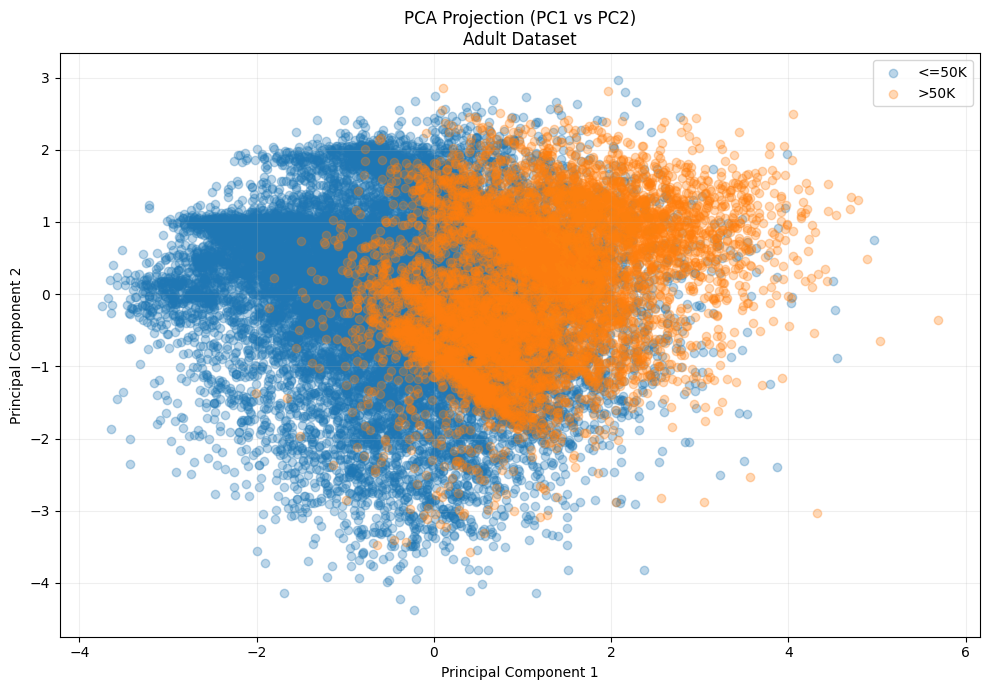

In [163]:
import matplotlib.pyplot as plt
import numpy as np

# Separar classes
high = (y == 1)
low  = (y == 0)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[low, 0],
    X_pca[low, 1],
    alpha=0.3,
    label="<=50K",
)

plt.scatter(
    X_pca[high, 0],
    X_pca[high, 1],
    alpha=0.3,
    label=">50K",
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection (PC1 vs PC2)\nAdult Dataset")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### O que cada eixo representa?

* **PC1 (eixo X)** → direção de maior variância do dataset.
* **PC2 (eixo Y)** → segunda maior direção de variância, ortogonal à primeira.

### O que vemos no gráfico?

* **Classe <=50K (azul)** → Concentrada majoritariamente na região esquerda (PC1 negativo).
* **Classe >50K (laranja)** → Mais concentrada na região direita (PC1 positivo).

### Insight principal

O PCA faz o seguinte: Ele procura a direção no espaço dos dados onde há maior variação entre as pessoas e essa direação se torna o PC1. Essa direção não tem nada a ver com renda diretamente, ele não sabe qual é a classe, ele apenas encontra qual a combinação de variáveis que mais diferencia as pessoas entre si. 

No gráfico, observamos que existe uma tendência de separação ao longo do PC1.

* À esquerda → predominância de <=50K
* À direita → predominância de >50K

Isso significa que a direção que mais diferencia as pessoas (PC1) também diferencia renda (o PC1 não tem conhecimento das classes), ou seja, a principal variação do dataset está alinhada com diferenças socioeconômica, em outras palavras, o componente principal está capturando um “gradiente socioeconômico”.

### Por que ainda há sobreposição?

Porque, o problema não é linearmente separável de forma perfeita. Muitas pessoas <=50K compartilham características com >50K, ou seja, há heterogeneidade interna nas classes.